In [1]:
import sys
sys.path.append('..')

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [3]:
# Code to make the Fermi data we will use with the public release
# Go 2-20 GeV
import numpy as np
import healpy as hp
from astropy.io import fits
#import propmod as pm

## 1. original make_data.py

In [19]:
# First load data and exposure
# 0 entry in units of [counts/cm^2/s/sr]
# exposure in [cm^2 s]

data_dir = '/zfs/tslatyer/fermimaps/allsky/PASS8_July16_UltracleanVeto/specbin/'
nsideload = 512
npixload = hp.nside2npix(nsideload)
pixarea = hp.nside2pixarea(nsideload)

# Setup energy bins
ebins_str = ['0002.0','0002.5', '0003.2','0004.0','0005.0',
             '0006.3','0008.0','0010.0','0012.6','0015.9','0020.0']
ebins = 2*np.logspace(-1,3,41)
de = ebins[1:] - ebins[:-1]
emid = 10**((np.log10(ebins[1:]) + np.log10(ebins[:-1]))/2.)

# Get the correct bins
de = de[10:20]
emid = emid[10:20]

# Load maps
counts = np.zeros(npixload)
expall = np.zeros(shape=(npixload,10))
pscmdl = np.zeros(npixload)
diff = np.zeros(npixload)

diffload = fits.open(data_dir + 'diffuse_model_map_healpix_p6v11_PASS8_July16_UltracleanVeto_bestpsf.fits')
diffall = diffload[0].data

print(diffall.shape)

(3145728, 40)


In [20]:
for i in range(10):
    load = fits.open(data_dir + 'fermi-allsky-' + ebins_str[i] + '-' + ebins_str[i+1] + 'GeV-fwhm000-0512-bestpsf-nopsc.fits')
    fi = load[0].data
    ei = load[1].data
    countsi = fi*ei*pixarea # [counts/pixel]
    counts += countsi
    expall[:,i] = ei

    # Diff has all 40, 2 GeV is i=10, so start there
    # NB!!! The diffuse model has different units to everything else.
    # It is already exposure corrected, but is divided by the bin size in MeV
    # I'm here copying the approach in the fermi plugin
    diff += diffall[:,i+10]*de[i] * 4.*np.pi/npixload * 10**3.

    load = fits.open(data_dir + 'fermi-allsky-' + ebins_str[i] + '-' + ebins_str[i+1] + 'GeV-fwhm000-0512-bestpsf-pscmdl.fits')
    pi = load[0].data

    pscmdl += pi*ei

# Round counts to be exact, some values slightly off an integer in above
counts = np.round(counts)
exp = np.mean(expall, axis=1)

# Load ps mask
load = fits.open('/zfs/nrodd/MakeNPTFitData/PtSourceMask/Allpscmask_3FGL-energy2.00000_0.95_ULTRACLEANVETO_bestpsf.fits') 
psmask = load[0].data

# Change nside to output value
nside = 128
npix = hp.nside2npix(nside)
counts = hp.ud_grade(counts,nside,power=-2)
exp = hp.ud_grade(exp,nside,power=0)
diff = hp.ud_grade(diff,nside,power=-2)
pscmdl = hp.ud_grade(pscmdl,nside,power=-2)

In [7]:
# Output exposure before any further manipulations, to avoid its value getting reset
# np.save('fermidata_exposure.npy', exp)

# Load the other templates - these are nside 256
# iso = exp
# load = fits.open('/zfs/nrodd/Templates/template_finenfw3.fits')
# temps = load[1].data
# bub = hp.ud_grade(temps[9][4],nside,power=-2)*exp
# nfw = hp.ud_grade(temps[195][4],nside,power=-2)*exp

# load = fits.open('raw_disk.fits')
# disk = hp.ud_grade(load[0].data,nside,power=-2)*exp

In [8]:
# Adjust templates to all have mean 1 in the ROI
# ROI: |b| >= 2, |r| <= 30

theta, phi = hp.pix2ang(nside, range(npix))
larr = np.zeros(npix)
for i in range(npix):
    #larr[i] = pm.mod(phi[i]+np.pi,2*np.pi)-np.pi
    larr[i] = ((phi[i]+np.pi) % (2*np.pi)) - np.pi
barr = np.pi/2 - theta
rarr = np.arccos(np.cos(larr)*np.cos(barr))

roi = np.where((np.abs(barr) >= 2*np.pi/180.) & (rarr <= 30*np.pi/180.))[0]

diff /= np.mean(diff[roi])
pscmdl /= np.mean(pscmdl[roi])
# iso  /= np.mean(iso[roi])
# bub  /= np.mean(bub[roi])
# nfw  /= np.mean(nfw[roi])
# disk /= np.mean(disk[roi])

# Now output
np.save('fermidata_counts.npy', counts)
np.save('fermidata_pscmask.npy', psmask)
np.save('template_dif.npy', diff)
# np.save('template_iso.npy',iso)
# np.save('template_bub.npy',bub)
# np.save('template_gce.npy',nfw)
np.save('template_psc.npy', pscmdl)
# np.save('template_dsk.npy',disk)

## 2. Process other sources

In [36]:
diff_name = 'p6v11'

data_dir = '/zfs/tslatyer/fermimaps/allsky/PASS8_July16_UltracleanVeto/specbin/'
nsideload = 512
npixload = hp.nside2npix(nsideload)
pixarea = hp.nside2pixarea(nsideload)

# Setup energy bins
ebins_str = ['0002.0','0002.5', '0003.2','0004.0','0005.0',
             '0006.3','0008.0','0010.0','0012.6','0015.9','0020.0']
ebins = 2*np.logspace(-1,3,41)
de = ebins[1:] - ebins[:-1]
emid = 10**((np.log10(ebins[1:]) + np.log10(ebins[:-1]))/2.)

# Get the correct bins
de = de[10:20]
emid = emid[10:20]

# init
diff = np.zeros(npixload)

diffload = fits.open(data_dir + f'diffuse_model_map_healpix_{diff_name}_PASS8_July16_UltracleanVeto_bestpsf.fits')
diffall = diffload[0].data
print(diffall.shape)

for i in range(10):
    # Diff has all 40, 2 GeV is i=10, so start there
    # NB!!! The diffuse model has different units to everything else.
    # It is already exposure corrected, but is divided by the bin size in MeV
    # I'm here copying the approach in the fermi plugin
    diff += diffall[:,i+10]*de[i] * 4.*np.pi/npixload * 10**3.

# Change nside to output value
nside = 128
npix = hp.nside2npix(nside)
diff = hp.ud_grade(diff, nside, power=-2)

# Adjust templates to all have mean 1 in the ROI
# ROI: |b| >= 2, |r| <= 30
theta, phi = hp.pix2ang(nside, range(npix))
larr = np.zeros(npix)
for i in range(npix):
    #larr[i] = pm.mod(phi[i]+np.pi,2*np.pi)-np.pi
    larr[i] = ((phi[i]+np.pi) % (2*np.pi)) - np.pi
barr = np.pi/2 - theta
rarr = np.arccos(np.cos(larr)*np.cos(barr))

roi = np.where((np.abs(barr) >= 2*np.pi/180.) & (rarr <= 30*np.pi/180.))[0]

diff /= np.mean(diff[roi])

np.save(f'template_{diff_name}.npy', diff)

(3145728, 40)


## A. Check

### A.1 dif template

In [37]:
dif1 = np.load('template_p6v11.npy')
dif2 = np.load('../data/fermi_data/template_dif.npy')
np.all(dif1==dif2)

True

### A.2 ccw A & F

In [17]:
from utils.cart import to_cart

In [31]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

In [38]:
template_dict = {
    k: to_cart(np.load(f'template_{k}.npy'), n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5)) \
    for k in ['ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem', 'p6v11']
}

[Text(0.5, 1.0, 'p6v11')]

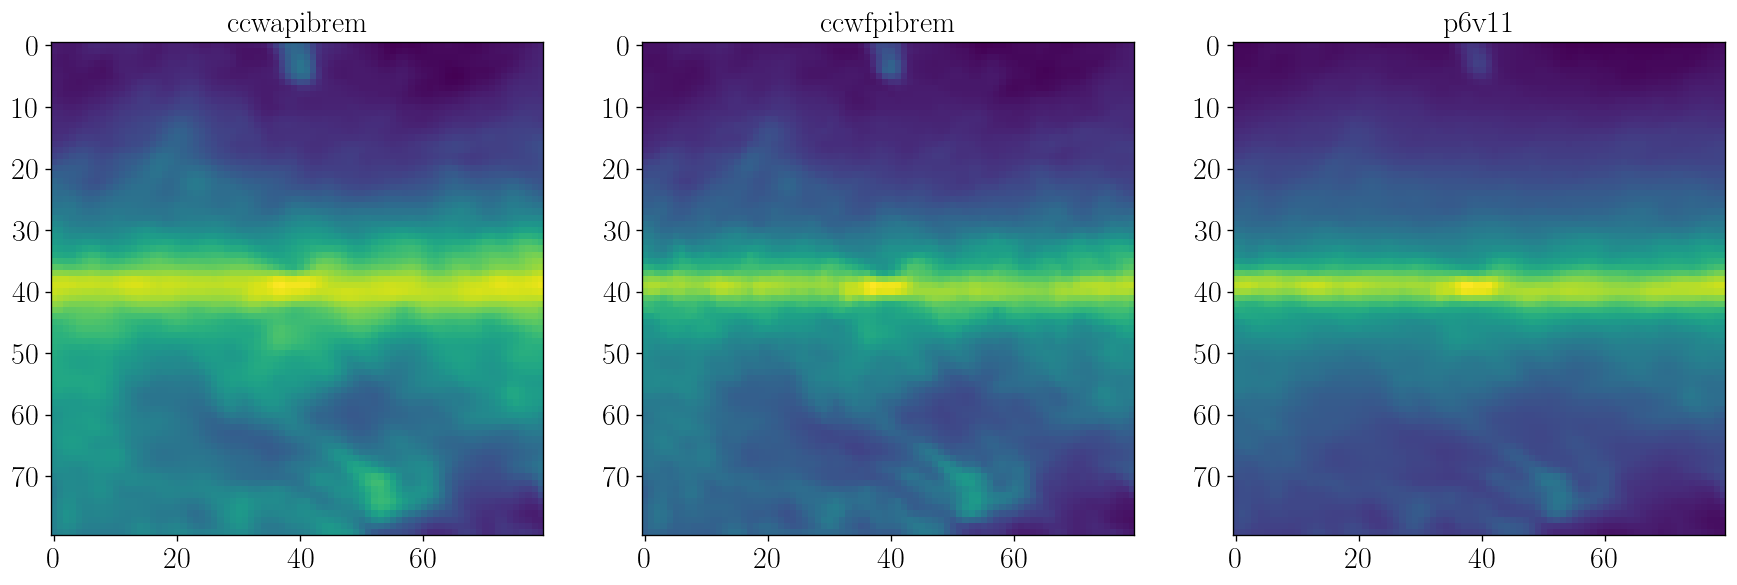

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(18,6))

axs[0].imshow(np.log10(template_dict['ccwapibrem']))
axs[0].set(title='ccwapibrem')
axs[1].imshow(np.log10(template_dict['ccwfpibrem']))
axs[1].set(title='ccwfpibrem')
axs[2].imshow(np.log10(template_dict['p6v11']))
axs[2].set(title='p6v11')

### A.3 counts

In [10]:
from utils.cart import to_cart

In [15]:
DATA_DIR = '/zfs/tslatyer/fermidata/exposure/pass8_718weeks'

In [21]:
# Load and downsamples Fermi counts data

counts_fits = fits.open(f"{DATA_DIR}/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts_718 = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts_718.shape[0] // upsample_factor
counts_downsampled = counts_718.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [22]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

/zfs/yitians/anaconda3/envs/fermi/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  


[Text(0.5, 1.0, '718 weeks')]

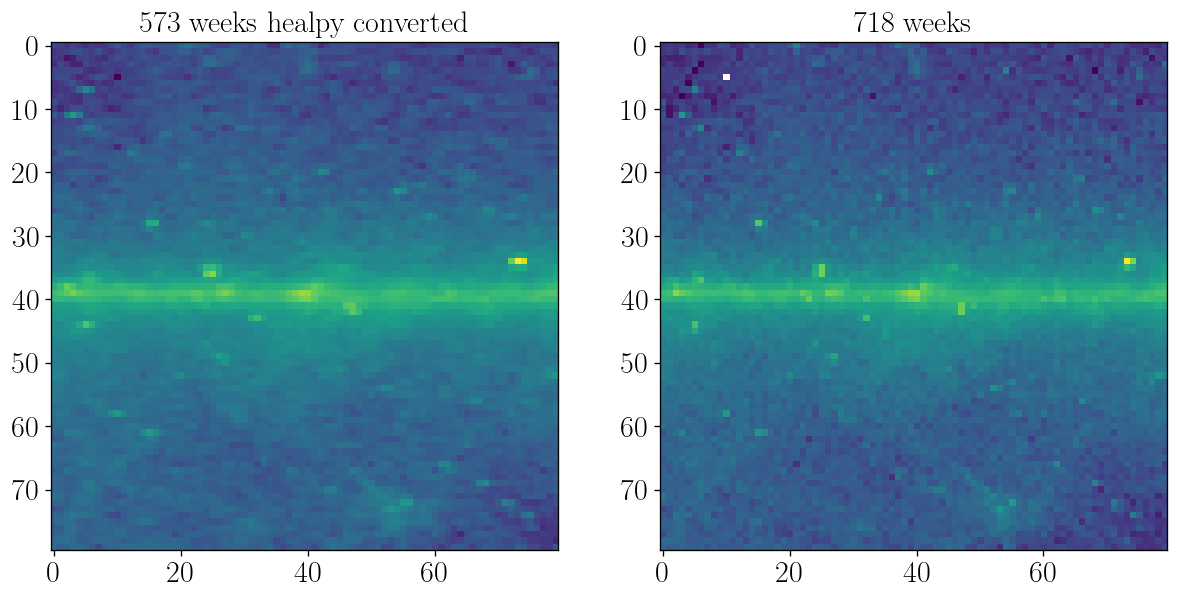

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

counts_573 = to_cart(counts, n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))

axs[0].imshow(np.log10(counts_573))
axs[1].imshow(np.log10(counts_downsampled))
axs[0].set(title='573 weeks healpy converted')
axs[1].set(title='718 weeks')